In [13]:
import re
import matplotlib.pyplot as plt
import os

def parse_log_file(log_path):
    """提取 Train Loss, Valid Loss 以及最终的 Test Loss"""
    epochs = []
    train_losses = []
    valid_losses = []
    best_epoch_log = None
    test_loss = None
    
    # 匹配损失记录
    loss_pattern = re.compile(r"Epoch\s+(\d+)/\d+\s+-\s+Train Loss:\s+([\d.]+)\s+-\s+Valid Loss:\s+([\d.]+)")
    # 匹配最终生成的 Best epoch 和 Test Loss (针对你提供的日志格式)
    test_pattern = re.compile(r"Best epoch :\s*(\d+)\.\s+Final Test Loss:\s+([\d.]+)")
    
    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            match = loss_pattern.search(line)
            if match:
                epochs.append(int(match.group(1)))
                train_losses.append(float(match.group(2)))
                valid_losses.append(float(match.group(3)))
            
            test_match = test_pattern.search(line)
            if test_match:
                best_epoch_log = int(test_match.group(1))
                test_loss = float(test_match.group(2))
                
    return epochs, train_losses, valid_losses, best_epoch_log, test_loss

def plot_loss_curve(epochs, train_losses, valid_losses, test_loss=None,
                    title="Training Details", train_color="#1f77b4", valid_color="#ff7f0e", 
                    line_width=2):
    """绘制自定义的 Loss 曲线"""
    plt.figure(figsize=(10, 6), dpi=120)
    
    # 画线
    plt.plot(epochs, train_losses, label='Train Loss', color=train_color, linewidth=line_width, alpha=0.85)
    plt.plot(epochs, valid_losses, label='Valid Loss', color=valid_color, linewidth=line_width, alpha=0.85)
    
    # 标出最佳点
    best_loss = min(valid_losses)
    best_epoch = epochs[valid_losses.index(best_loss)]
    
    plt.axvline(x=best_epoch, color='#FF6B6B', linestyle=':', alpha=0.7, 
                label=f'Best Epoch')
    plt.scatter([best_epoch], [best_loss], color='red', s=50, zorder=5)

    # 如果解析到了Test Loss，加入到图例中
    if test_loss is not None:
        plt.plot([], [], ' ', label=f'Test Loss: {test_loss:.2f}')

    # 样式修饰
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    
    plt.grid(True, which='major', linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right', shadow=True)

    plt.tight_layout()
    plt.show()

成功提取 201 条历次损失记录。
提取到最终测试集损失 (Test Loss): 3125.5387


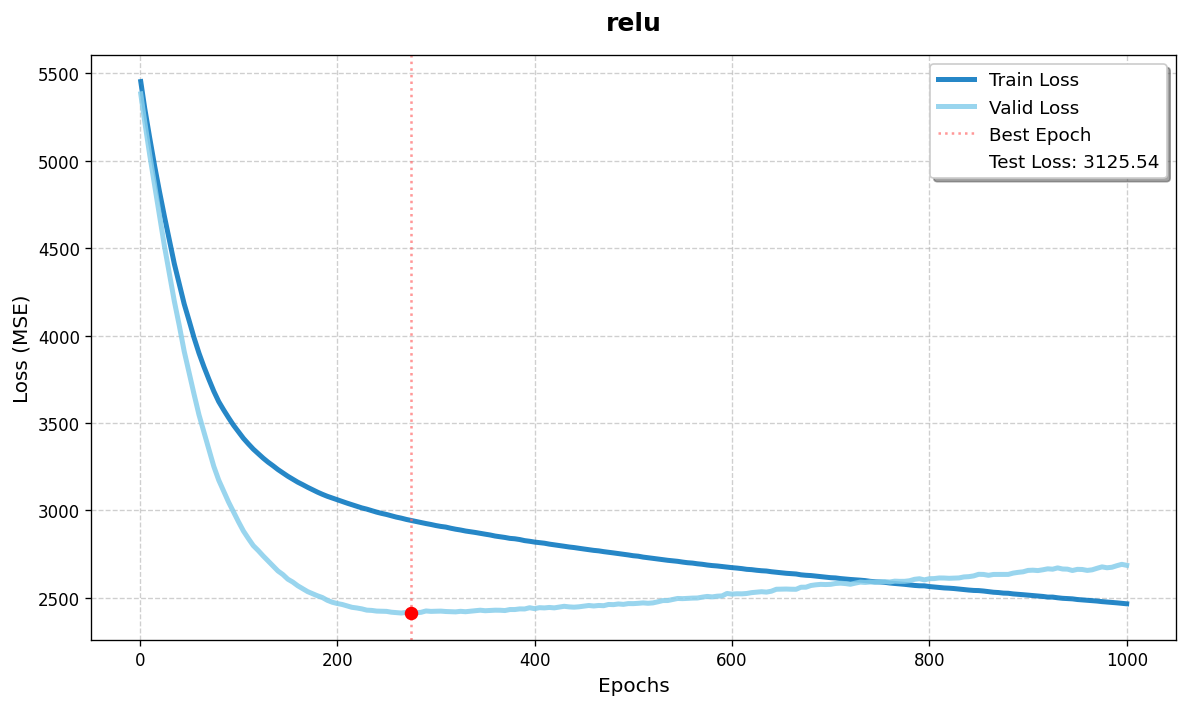

In [29]:
# 获取上一层目录 result 下的特定日志文件
log_file_path = r"../result/depth_fnn_medium_relu_lr0.001_bsz32_optsgd/depth_fnn_medium_relu_lr0.001_bsz32_optsgd.log"

if os.path.exists(log_file_path):
    # 提取数据
    eps, t_loss, v_loss, best_ep, test_l = parse_log_file(log_file_path)
    
    if len(eps) > 0:
        print(f"成功提取 {len(eps)} 条历次损失记录。")
        print(f"提取到最终测试集损失 (Test Loss): {test_l}")
        
        # 调用绘图函数
        plot_loss_curve(
            epochs=eps, 
            train_losses=t_loss, 
            valid_losses=v_loss,
            test_loss=test_l,               # 将测试集结果传入显示在图例中
            title="relu",
            train_color="#0072BD",        # 自由修改线条颜色
            valid_color="#87CEEB", 
            line_width=3
        )
    else:
        print("未提取到数据，请检查日志格式。")
else:
    print(f"文件不存在: {log_file_path}")